In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
from src.utils import load_json
from src.data.graph import EdgeType

In [3]:
DATASETS = ["dataset1", "dataset2"]

$\mathcal{KG}$

In [4]:
def num_nodes_kg(node_file, decision_file):
    nodes = load_json(node_file)
    raw = pd.read_csv(decision_file)
    raw_nodes = raw["QID"].unique().tolist()
    raw_nodes += raw["from"].unique().tolist()
    return len(nodes) + len(set(raw_nodes))

In [5]:
def num_edges_kg(edge_part_root):
    count = 0
    for edge_part in os.listdir(edge_part_root):
        count += len(load_json(f"{edge_part_root}/{edge_part}"))
    return count

In [6]:
def load_edge_types_kg(edge_part_root):
    edge_types = set()
    for edge_part in os.listdir(edge_part_root):
        edges = load_json(f"{edge_part_root}/{edge_part}")
        for edge in edges:
            edge_types.add(EdgeType(**edge["edge_type"]))
    return len(list(edge_types))

$\mathcal{SG}$

In [7]:
def num_node_types_nodes_sg(node_file):
    return len(load_json(node_file))

def num_edge_types_nodes_sg(edge_file):
    edge_types = set()
    edges = load_json(edge_file)
    for edge in edges:
        edge_types.add(edge["itemLabel"])
    return len(list(edge_types))

def num_nodes_sg(node_file, edge_file):
    return num_node_types_nodes_sg(node_file) + num_edge_types_nodes_sg(edge_file)

def num_edges_sg(edge_file):
    return 2 * len(load_json(edge_file))

def num_named_relations_sg():
    return 2

$\mathcal{G}$

In [8]:
def num_nodes_g(node_types, nodes):
    count = 0
    count += len(load_json(node_types))
    node_dict = load_json(nodes)
    count += len([d for d in node_dict if d["cls_idx"] != -1])
    return count

def num_edges_g(part_root):
    count = 0
    for part in os.listdir(part_root):
        count += len([d for d in load_json(f"{part_root}/{part}") if d["edge_type"]["target"] == "1"])
    return count

def num_named_relations_g(edge_file):
    return len(load_json(edge_file))

In [9]:
dataset_statistics_dict = {
    dataset: {
        "kg nodes": num_nodes_kg(f"data/processed/{dataset}/nodes.json", f"data/raw/pruning-datasets/{dataset}/{dataset}_gold_decisions_filtered.csv"),
        "kg edges": num_edges_kg(f"data/processed/{dataset}/edges/partition"),
        "kg named relations": load_edge_types_kg(f"data/processed/{dataset}/edges/partition"),
        
        "sg nodes": num_nodes_sg(f"data/processed/{dataset}/node_types/summarization/qwen3-8b/node_type_info.json", f"data/processed/{dataset}/edge_types/summarization/qwen-8b/edge_type_info.json"),
        "sg edges": num_edges_sg(f"data/processed/{dataset}/edge_types/summarization/qwen-8b/edge_type_info.json"),
        "sg named relations": num_named_relations_sg(),
        
        "g nodes": num_nodes_g(f"data/processed/{dataset}/node_types/summarization/qwen3-8b/node_type_info.json", f"data/processed/{dataset}/nodes.json"),
        "g edges": num_edges_g(f"data/processed/{dataset}/edges/partition"),
        "g named relations": num_named_relations_g(f"data/processed/{dataset}/edge_types/summarization/qwen-8b/edge_type_info.json")
    }
    for dataset in DATASETS
}
dataset_statistics_df = pd.DataFrame.from_dict(dataset_statistics_dict, orient="index")
dataset_statistics_df

,kg nodes,kg edges,kg named relations,sg nodes,sg edges,sg named relations,g nodes,g edges,g named relations
dataset1,304982,299193,46295,5030,58868,2,233013,249186,29434
dataset2,82044,59393,6568,1279,8606,2,72915,54920,4303


In [10]:
print(dataset_statistics_df.to_latex())

\begin{tabular}{lrrrrrrrrr}
\toprule
 & kg nodes & kg edges & kg named relations & sg nodes & sg edges & sg named relations & g nodes & g edges & g named relations \\
\midrule
dataset1 & 304982 & 299193 & 46295 & 5030 & 58868 & 2 & 233013 & 249186 & 29434 \\
dataset2 & 82044 & 59393 & 6568 & 1279 & 8606 & 2 & 72915 & 54920 & 4303 \\
\bottomrule
\end{tabular}



In [11]:
df = pd.DataFrame(load_json("data/processed/dataset1/nodes.json"))
df = df[df["cls_idx"] != -1]

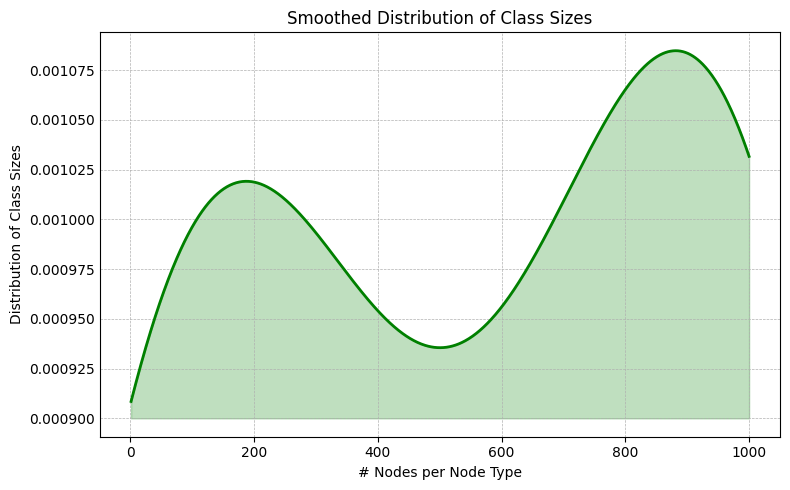

In [12]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
class_sizes = df.groupby('cls_idx').size() 
# Step 2: discrete distribution (percentage of classes) 
size_counts = class_sizes.value_counts().sort_index() 
x_discrete = size_counts.index.values 
y_discrete = size_counts.values / size_counts.values.sum() # percentage (0–1) # Step 3: smooth it with KDE (weighted) 
kde = gaussian_kde(x_discrete, weights=y_discrete) # High-resolution curve 
x = np.linspace(x_discrete.min(), x_discrete.max(), 1000) 
y = kde(x) # Normalize to make it a proper percentage curve 
y = y / y.sum() # Plot 
y_base = np.ones_like(x, dtype=float) * 0.0009
# Plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, y_base, color="green", alpha=0.25)
plt.plot(x, y, color="green", linewidth=2)

# Remove full y-axis (ticks + labels + spine)
ax = plt.gca()
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)

plt.xlabel("# Nodes per Node Type")
plt.ylabel("Distribution of Class Sizes")
plt.title("Smoothed Distribution of Class Sizes")

plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("./reports/dataset1-node-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

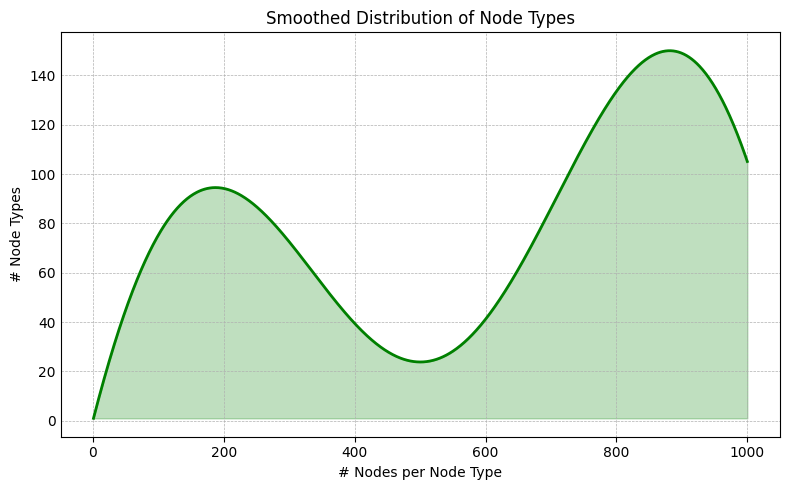

In [13]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
class_sizes = df.groupby('cls_idx').size() 
# Step 2: discrete distribution (percentage of classes) 
size_counts = class_sizes.value_counts().sort_index() 
x_discrete = size_counts.index.values 
y_discrete = size_counts.values / size_counts.values.sum() # percentage (0–1) # Step 3: smooth it with KDE (weighted) 
kde = gaussian_kde(x_discrete, weights=y_discrete) # High-resolution curve 
x = np.linspace(x_discrete.min(), x_discrete.max(), 1000) 
y = kde(x) # Normalize to make it a proper percentage curve 
y = y / y.sum() # Plot 

# Rescale to actual frequency range
y_min = size_counts.values.min()
y_max = size_counts.values.max()

y = (y - y.min()) / (y.max() - y.min())
y = y * (y_max - y_min) + y_min

y_base = np.ones_like(x, dtype=float) * y.min()
# Plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, y_base, color="green", alpha=0.25)
plt.plot(x, y, color="green", linewidth=2)

# Remove full y-axis (ticks + labels + spine)
ax = plt.gca()
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)

plt.xlabel("# Nodes per Node Type")
plt.ylabel("# Node Types")
plt.title("Smoothed Distribution of Node Types")

plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("./reports/dataset1-node-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [14]:
def load_edge_distribution(edge_part_root, edge_component_mapping):
    mapping = load_json(edge_component_mapping)
    mapping = {tuple(d["edge_type"]): d["component_id"] for d in mapping}
    distribution = {idx: 0 for idx in set(mapping.values())}

    for partition in os.listdir(edge_part_root):
        edges = load_json(f"{edge_part_root}/{partition}")
        for edge in edges:
            edge_type = edge["edge_type"]
            edge_type = (edge_type["head_cls"], edge_type["pid"], edge_type["tail_cls"])
            if -1 in edge_type:
                continue
            component_id = mapping.get(edge_type)
            distribution[component_id] += 1
    return distribution

In [15]:
distribution = load_edge_distribution("data/processed/dataset1/edges/partition", "data/processed/dataset1/edges/edge_component_mapping.json")

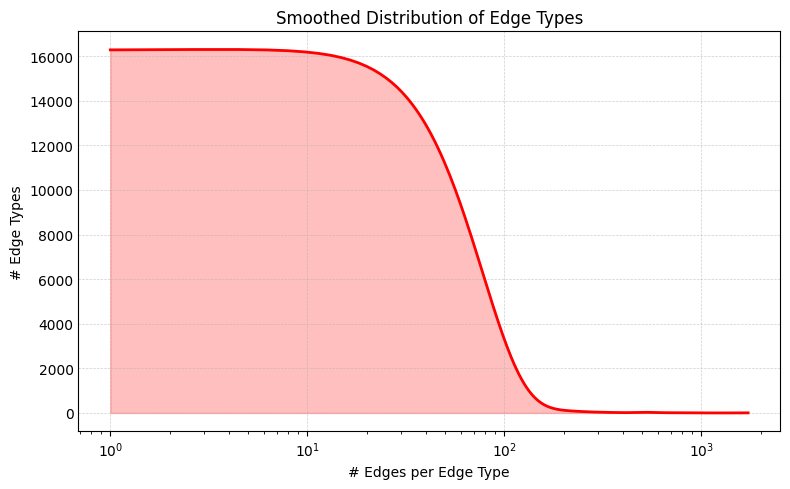

In [16]:
values = np.array(list(distribution.values()), dtype=float)

# discrete empirical distribution
unique_vals, counts = np.unique(values, return_counts=True)
# counts = counts / counts.sum()

# KDE (weighted)
kde = gaussian_kde(unique_vals, weights=counts)

# smooth curve
x = np.linspace(unique_vals.min(), unique_vals.max(), 1000)
y = kde(x)

y_max = counts.max()
y_min = counts.min()

# normalize as proper density
y = (y - y.min()) / (y.max() - y.min())
y = y * (y_max - y_min) + y_min

y_base = np.ones_like(x, dtype=float) * y.min()

# plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, 0, color="red", alpha=0.25)
plt.plot(x, y, color="red", linewidth=2)

ax = plt.gca()

# remove y-axis numbers (your style choice)
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)


plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.xscale('log')
plt.xlabel("# Edges per Edge Type")
plt.ylabel("# Edge Types")
plt.title("Smoothed Distribution of Edge Types")

plt.tight_layout()
plt.savefig("./reports/dataset1-edge-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

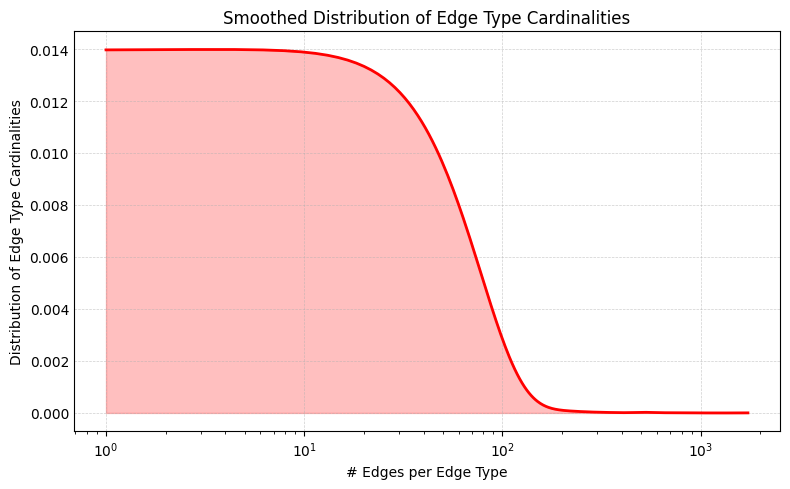

In [17]:
values = np.array(list(distribution.values()), dtype=float)

# discrete empirical distribution
unique_vals, counts = np.unique(values, return_counts=True)
counts = counts / counts.sum()

# KDE (weighted)
kde = gaussian_kde(unique_vals, weights=counts)

# smooth curve
x = np.linspace(unique_vals.min(), unique_vals.max(), 1000)
y = kde(x)

# normalize as proper density
y = y / np.trapezoid(y, x)

# plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, 0, color="red", alpha=0.25)
plt.plot(x, y, color="red", linewidth=2)

ax = plt.gca()

# remove y-axis numbers (your style choice)
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)


plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.xscale('log')
plt.xlabel("# Edges per Edge Type")
plt.ylabel("Distribution of Edge Type Cardinalities")
plt.title("Smoothed Distribution of Edge Type Cardinalities")

plt.tight_layout()
plt.savefig("./reports/dataset1-edge-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

DATASET 2

In [18]:
df = pd.DataFrame(load_json("data/processed/dataset2/nodes.json"))
df = df[df["cls_idx"] != -1]

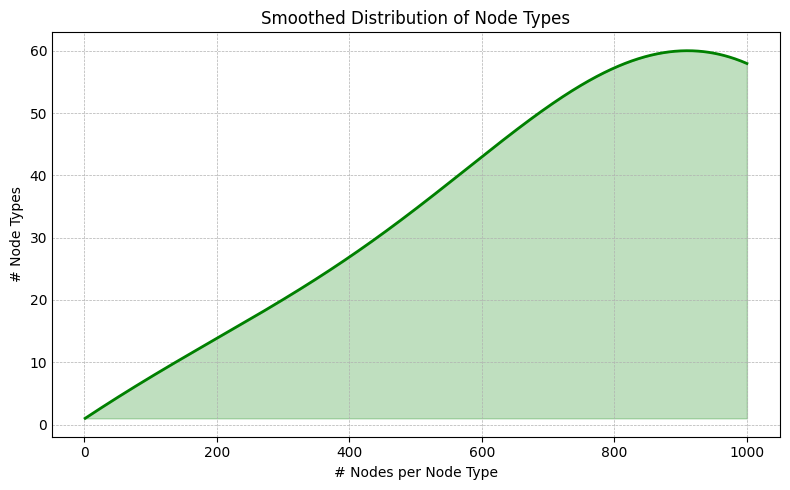

In [19]:
class_sizes = df.groupby('cls_idx').size() 
# Step 2: discrete distribution (percentage of classes) 
size_counts = class_sizes.value_counts().sort_index() 
x_discrete = size_counts.index.values 
y_discrete = size_counts.values / size_counts.values.sum() # percentage (0–1) # Step 3: smooth it with KDE (weighted) 
kde = gaussian_kde(x_discrete, weights=y_discrete) # High-resolution curve 
x = np.linspace(x_discrete.min(), x_discrete.max(), 1000) 
y = kde(x) # Normalize to make it a proper percentage curve 
y = y / y.sum() # Plot 
# Rescale to actual frequency range
y_min = size_counts.values.min()
y_max = size_counts.values.max()

y = (y - y.min()) / (y.max() - y.min())
y = y * (y_max - y_min) + y_min

y_base = np.ones_like(x, dtype=float) * y.min()
# Plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, y_base, color="green", alpha=0.25)
plt.plot(x, y, color="green", linewidth=2)

# Remove full y-axis (ticks + labels + spine)
ax = plt.gca()
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)

plt.xlabel("# Nodes per Node Type")
plt.ylabel("# Node Types")
plt.title("Smoothed Distribution of Node Types")

plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig("./reports/dataset2-node-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [20]:
distribution = load_edge_distribution("data/processed/dataset2/edges/partition", "data/processed/dataset2/edges/edge_component_mapping.json")

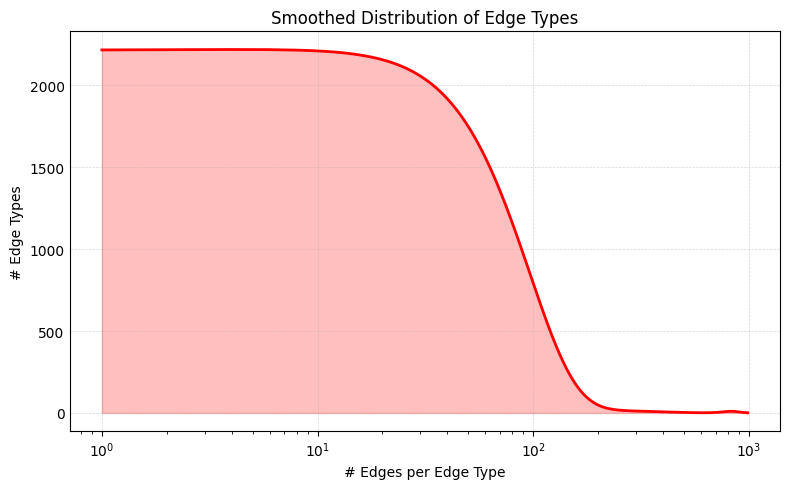

In [21]:
values = np.array(list(distribution.values()), dtype=float)

# discrete empirical distribution
unique_vals, counts = np.unique(values, return_counts=True)
# counts = counts / counts.sum()

# KDE (weighted)
kde = gaussian_kde(unique_vals, weights=counts)

# smooth curve
x = np.linspace(unique_vals.min(), unique_vals.max(), 1000)
y = kde(x)

y_max = counts.max()
y_min = counts.min()

# normalize as proper density
y = (y - y.min()) / (y.max() - y.min())
y = y * (y_max - y_min) + y_min

y_base = np.ones_like(x, dtype=float) * y.min()

# normalize as proper density
# y = y / np.trapezoid(y, x)

# plot
plt.figure(figsize=(8, 5))

plt.fill_between(x, y, 0, color="red", alpha=0.25)
plt.plot(x, y, color="red", linewidth=2)

ax = plt.gca()

# remove y-axis numbers (your style choice)
# ax.set_yticklabels([])
ax.tick_params(axis='y', length=0)


plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.xscale('log')
plt.xlabel("# Edges per Edge Type")
plt.ylabel("# Edge Types")
plt.title("Smoothed Distribution of Edge Types")

plt.tight_layout()
plt.savefig("./reports/dataset2-edge-distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()